# Mahalanobis Distance Detection Filtering

Author(s) - Ryan Folks  
Purpose - To investigate the use of the Mahalanobis distance between new detections and observed distributions of the location of ground truth anchors on observed sheets.

---

In [88]:
import sys
import os
sys.path.append(os.path.join("..", "..", "..", "ChartExtractor", "src"))

In [152]:
from utilities.annotations import BoundingBox
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import json
import random
from typing import Dict, List
from pathlib import Path

In [2]:
RANDOM_SEED: int = 0

## 0 - Abstract

## 1 - Introduction

### 1.0 - Describing the Mahalanobis Distance

[The Mahalanobis distance](https://en.wikipedia.org/wiki/Mahalanobis_distance) quantifies the distance between a point $p \in \mathbb{R}^{n}$ and a distribution of points $D$ on $\mathbb{R}^n$.  
The benefit of the mahalanobis distance over another distance metric like Euclidean or Manhattan distance is that the Mahalanobis distance takes into account the dispersion of the data,
or more properly, the covariance. 

<Axes: >

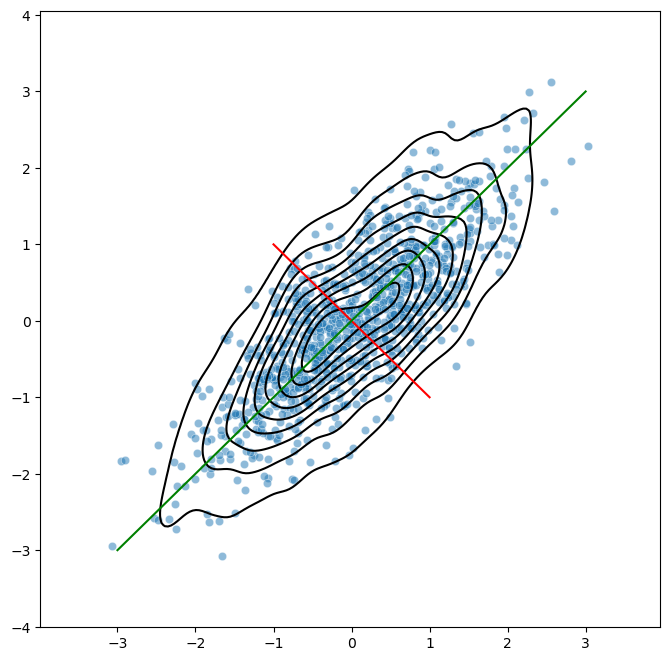

In [16]:
np.random.seed(RANDOM_SEED)
fig, ax = plt.subplots(figsize=(8, 8))

data = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]], size=1000)
sns.scatterplot(
    x=[x for (x, y) in data.tolist()], 
    y=[y for (x, y) in data.tolist()],
    alpha=0.5
)
sns.kdeplot(
    x=[x for (x, y) in data.tolist()], 
    y=[y for (x, y) in data.tolist()],
    color="black"
)
sns.lineplot(
    x=[-1, 1],
    y=[1, -1],
    color="red"
)
sns.lineplot(
    x=[-3, 3],
    y=[-3, 3],
    color="green"
)

The preceeding data's covariance is strong, so a single unit of change along the line $y=x$ (green line) is not as important as a single unit of change along the line $y=-x$ (red line).  
This is shown in the above image using the two lines. Both lines cover the distribution along their respective axis, but the green line needs to be three times the length of the red line to do so.  

Thus, any distance metric that gave equal weight to changes along both lines would be biased to changes along the green line. The Mahalanobis distance was created to adjust for just this kind of covariance.

### 1.1 - The Issue of Erroneous Detections

In order to perform non-linear registration on the images, dozens of document landmarks need to be detected by the model. Even if the model was very, very good, its accuracy being 99%, then we would still *expect*
at least one erroneous detection, improperly classified detection, or missed detection. 

If these erroneous detections are not filtered or fixed, they will destroy image quality rather than improve it by mapping a document landmark to an improper location.  
We can use the structure of the document to fix these detections.

### 1.2 - How The Mahalanobis Distance can Filter Erroneous Detections

By taking a training sample from our observed dataset (roughly 75% of it), and creating a distribution for each document landmark using the datapoints in the training sample 
(ie: a distribution for 'patient profile', and another for 'age'), we can find a distribution of points to satisfy our distribution $D$. All new points $p$ will have a distance
between them and the distribution $D$, and we will be able to determine if a detection is erroneous by setting a distance threshold.

## 2 - Experiment

### 2.0 - Computing The Mahalanobis Distance

(from wikipedia)  
Given a probability distribution $Q$ on $\mathbb{R}^{N}$, with mean $\overrightarrow\mu = (\mu_1, \mu_2, \ldots, \mu_N)^T$ and positive semi-definite covariance matrix $S$, the Mahalanobis distance of a point
$\overrightarrow{x} = (x_1, x_2, \ldots, x_N)^T$ from $Q$ is  

$$d_M(\overrightarrow{x}, Q) = \sqrt{(\overrightarrow{x}-\overrightarrow{\mu})^T S^{-1} (\overrightarrow{x}-\overrightarrow{\mu})}$$  

Since $S$ is a covariance matrix, it is positive semi-definite, so we can guarantee that $S^{-1}$ always exists.

In [65]:
def mahalanobis_distance(p:np.array, Q:np.matrix) -> float:
    """The Mahalanobis distance is a distance metric between a point `p` and a distribution of points `Q`.

    Args:
        `p` (np.array):
            The point to measure distance to.
        `Q` (np.matrix):
            The distribution of points to measure distance from.

    Returns:
        The Mahalanobis distance between `p` and `Q`.
    """
    if len(Q) != len(p) and len(Q.T) != len(p):
        raise ValueError(f"Mismatching dimensions between p and Q, (Dim p={len(p)}, Dim Q={len(Q)}).")
    elif len(Q) != len(p) and len(Q.T) == len(p):
        raise ValueError(f"Mismatching dimensions between p and Q, (Dim p={len(p)}, Dim Q={len(Q)}), but Q transpose does have matching dimensions. Did you mean Q.T?")
    
    S_inv: np.matrix = np.linalg.inv(np.cov(Q))
    mu: np.array = np.array([np.mean(Q[0]), np.mean(Q[1])])
    return np.sqrt(np.matmul(np.matmul((p-mu)[np.newaxis], S_inv), (p-mu))).item()

mahalanobis_distance(np.array([0.25, 0.42]), data.T)

0.4397831577390781

### 2.1 - Loading Observed Document Landmark Data

Now we need to load the previously observed data so we can get the distributions for landmarks.

In [147]:
json_data: List[Dict] = json.loads(
    open(
        str(Path("..")/".."/"data"/"preoperative_document_landmarks.json")
    ).read()
)

bbox_data: Dict[str, List[BoundingBox]] = {
    sheet_data['data']['image'].split("-")[-1]:[
        BoundingBox(
            category=label['value']['rectanglelabels'][0],
            left=label['value']['x']/100,
            top=label['value']['y']/100,
            right=label['value']['x']/100+label['value']['width']/100,
            bottom=label['value']['y']/100+label['value']['height']/100,
        )
        for label in sheet_data['annotations'][0]['result']
    ]
    for sheet_data in json_data
}

In [148]:
squash_list = lambda l: [x for y in l for x in y]

squashed_label_data = squash_list([
    [
        (key, bbox.category, bbox.left, bbox.top, bbox.right, bbox.bottom)
        for bbox in value
    ]
    for (key, value) in bbox_data.items()
])

label_df = pd.DataFrame(squashed_label_data, columns=["sheet_name", "label", "left", "top", "right", "bottom"])
label_df

,sheet_name,label,left,top,right,bottom
0,RC_0001_preoperative_postoperative.JPG,patient_profile,0.037649,0.065215,0.103534,0.077680
1,RC_0001_preoperative_postoperative.JPG,medical_history,0.037346,0.161129,0.109462,0.174292
2,RC_0001_preoperative_postoperative.JPG,prior_conditions,0.222171,0.180637,0.282531,0.190367
3,RC_0001_preoperative_postoperative.JPG,surgical_history,0.662722,0.175431,0.721459,0.187391
4,RC_0001_preoperative_postoperative.JPG,allergy,0.037977,0.313209,0.065322,0.324286
...,...,...,...,...,...,...
735,RC_0019_preoperative_postoperative.JPG,surgical_approach,0.109059,0.458225,0.177147,0.470295
736,RC_0019_preoperative_postoperative.JPG,surgical_history,0.691188,0.150116,0.751021,0.162193
737,RC_0019_preoperative_postoperative.JPG,time_of_assessment,0.051037,0.057447,0.126273,0.067117
738,RC_0019_preoperative_postoperative.JPG,urgency,0.229364,0.363330,0.260941,0.373386


Ensuring the labels are correct.

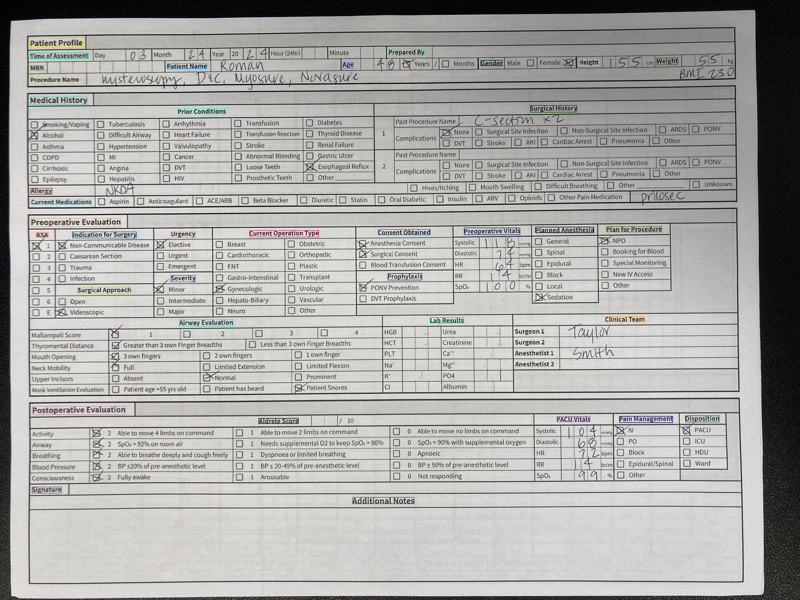

In [156]:
generate_color = lambda: "#%06x" % random.randint(0, 0xFFFFFF)

sheet = "RC_0001_preoperative_postoperative.JPG"
img = Image.open(str(Path("..")/".."/"data"/"chart_images"/sheet))
width, height = img.size
draw = ImageDraw.Draw(img)

for ix, row in label_df[label_df["sheet_name"] == sheet].iterrows():
    box = [
        row["left"]*width,
        row["top"]*height,
        row["right"]*width,
        row["bottom"]*height,
    ]
    draw.rectangle(box, outline=generate_color(), width=3)
img.resize((800, 600))

### 2.2 - The Mahalanobis Filter

## 3 - Results

### 3.0 - Testing the Efficacy of The Filter on Erroneous Detections

### 3.1 - Testing the Ability of the Filter to *Not* Filter True Detections

## 4 - Conclusion